# 

$$
\newcommand{\ip}[2]{\langle#1,#2\rangle}
\newcommand{\norm}[1]{\|#1\|}
\newcommand{\abs}[1]{\left|#1\right|}
\newcommand{\T}{\text{${}^{\text{T}}$}}
\newcommand{\R}{\mathbb{R}}
\newcommand{\argmin}[1]{\underset{#1}{\operatorname{argmin}}}
$$

In [62]:
import Pkg; Pkg.add("Wavelets"); Pkg.add("InteractiveViz")
using Wavelets, LinearAlgebra, Plots, ContinuousWavelets, Random

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
   Installed ImageIO ───────────────────── v0.6.9
   Installed StatsFuns ─────────────────── v1.5.0
   Installed PNGFiles ──────────────────── v0.4.4
   Installed JpegTurbo ─────────────────── v0.1.6
   Installed TiffImages ────────────────── v0.11.3
   Installed AdaptivePredicates ────────── v1.2.0
   Installed EarCut_jll ────────────────── v2.2.4+0
   Installed PDMats ────────────────────── v0.11.35
   Installed Sixel ─────────────────────── v0.1.3
   Installed StaticArrays ──────────────── v1.9.13
   Installed ProgressMeter ─────────────── v1.10.4
   Installed EnumX ─────────────────────── v1.0.5
   Installed OpenEXR ───────────────────── v0.3.3
   Installed CEnum ─────────────────────── v0.5.0
   Installed Netpbm ────────────────────── v1.1.1
   Installed FileIO ────────────────────── v1.17.0
   Inst

LoadError: ArgumentError: Package ContinuousWavelets not found in current path.
- Run `import Pkg; Pkg.add("ContinuousWavelets")` to install the ContinuousWavelets package.

This tutorial mostly uses the Wavelets.jl toolbox to analyse signals and
gain understanding. Refer to [Wavelets.jl
docs](https://github.com/JuliaDSP/Wavelets.jl) and the
[ContinuousWavelets.jl
docs](https://github.com/UCD4IDS/ContinuousWavelets.jl) for function
syntax. 

# Q1. Denoising

Consider the signal with added noise

In [78]:
t = 0:0.001:1
t = t/1023
y = sin.(2π*10*t) + 0.5*randn(length(t))

1001-element Vector{Float64}:
  0.03322886860025531
  0.11997990121730184
  0.3493085651312302
  0.8718520375340199
  0.41547493745995545
  0.38964031278228084
  0.8158146976219346
  1.074741585458656
  0.21644959089061766
  0.22505729180522782
  0.05641676980462328
 -0.6480223491481757
  0.9565552156246585
  ⋮
  0.1033431257978473
 -0.3875990498507149
 -0.5472635827860276
 -0.11621300456533425
  0.2927446575781403
 -0.06226718657257784
  0.6121476366950026
  0.3197304442633367
  0.35975726761157817
  0.683139625596932
  0.553307142201561
 -0.23385718508970496

(a)  Use `denoise` from Wavelets.jl with different thresholds (hard/soft)
    for Haar.

In [79]:
# Pad to nearest power of 2
function pad_to_power_of_2(signal)
    n = length(signal)
    next_pow2 = 2^ceil(Int, log2(n))
    padded = zeros(eltype(signal), next_pow2)
    padded[1:n] = signal
    return padded
end

# Create original signal with noise
y_original = sin.(2π*10*t)
y_noisy = y_original + 0.5*randn(length(t))

# Pad the signal
y_padded = pad_to_power_of_2(y_noisy)

# Define Haar wavelet
wave_haar = wavelet(WT.haar)
wave_haar = WT.scale(wave_haar, 1/sqrt(2))

# Denoise with TI (Translation Invariant) option
denoised_padded = denoise(y_padded, wave_haar, TI=true)

# Extract original part
denoised = denoised_padded[1:length(y_noisy)]

1001-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

(b)  Visual the denoised signals vs the original and the noisy signal.

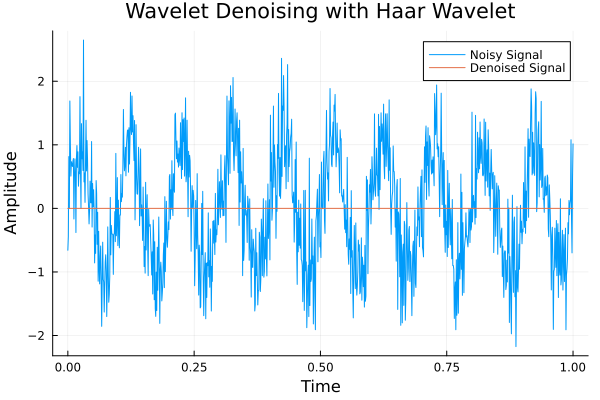

In [75]:
using Plots
plot(t, y_noisy, label="Noisy Signal")
plot!(t, denoised, label="Denoised Signal")
xlabel!("Time")
ylabel!("Amplitude")
title!("Wavelet Denoising with Haar Wavelet")

(c)  Compute the SNR improvement

(d) Repeat steps (a)-(c) for the DB4 wavelet

(e)  What difference do you notice between the two wavelets in terms of
    denoising quality?

# Q2. Time-Frequency Analysis

Here is an example of using the continuous wavelet transform to analyse a signal.

In [3]:
# Morlet wavelet configuration
c = wavelet(Morlet(π), β=2, averagingType=NoAve())
res = cwt(doppler_signal, c)

# scalogram visualization
heatmap(abs.(res)', c=:viridis, 
        title="CWT Scalogram", 
        xlabel="time", 
        ylabel="scalee")

LoadError: UndefVarError: `Morlet` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Consider the chip signal:

In [4]:
t = 0:0.001:1
y = sin.(2π*100*t.^2);

1.  Plot it

(a)  Use a continuous wavelet transform (CWT) with the Morlet wavelet on
    $y$.

(b) Generate a scalogram using `heatmap`.

(c) Where on the scalogram is the time-frequency localisation of the
    dominant components?

# Q3. Wavelet vs. Fourier

Consider the following signals:

In [5]:
bumps_signal = testfunction(length(t), "Bumps")

doppler_signal = testfunction(length(t), "Doppler")

plot(t, [bumps_signal doppler_signal],
     label=["Bumps" "Doppler"],
     xlabel="Time (s)",
     ylabel="Amplitude",
     linewidth=2)

LoadError: UndefVarError: `testfunction` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

(a)  Plot the Fourier spectrum and D4 wavelet coefficients

(b)  Explain which method better localises the transient events and why.